In [34]:
# Importing Libraries:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import zipfile
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [35]:
# Check if the file exists in the expected path
# path = '/content/drive/My Drive/EV_CleanedDataset.csv'
# if os.path.exists(path):
#     print(f"File found at: {path}")
# else:
#     print(f"File NOT found at: {path}")


In [36]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Loading Cleaned Dataset:
df = pd.read_csv('/content/drive/My Drive/EV_CleanedDataset.csv')
# Look at the Dataset:
df.head()


,account,premise_desc_code,size,customer_type,heating_type,heating_group,last_yr_kwh_usage,last_yr_avg_kwh_usage,geo_area_code,city,...,children_desc_code,can_afford_ev,est_rate_code,recently_bought_home,est_social_media_income,est_alternative_financing,EVFlag,energy_efficiency_index,affordability_index,sustainability_interest_index
0,1,DU,SMALL,MULTI FAMILY- ELECTRIC,ELECTRIC BASEBOARD,Electric,16279.0,1281.0,0.0,0.0,...,0.0,0.68,0.0,0.0,0.0,0.86,0.0,10.048765,0.00,0.0
1,2,SF,MED,SINGLE FAMILY - OTHER HEAT,GAS FURNACE,Non-Electric,48531.0,6036.0,1.0,1.0,...,1.0,0.76,0.0,0.0,1.0,0.87,0.0,12.711105,0.24,0.0
2,3,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,9801.0,846.0,2.0,2.0,...,0.0,0.96,0.0,0.0,0.0,0.82,0.0,3.296670,0.08,1.0
3,4,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,9801.0,846.0,2.0,2.0,...,0.0,0.96,0.0,0.0,0.0,0.82,0.0,3.296670,0.08,1.0
4,5,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,7408.0,602.0,2.0,2.0,...,0.0,0.96,0.0,0.0,0.0,0.82,0.0,2.491759,0.08,1.0


In [38]:
# Look at the Shape
df.shape

(393854, 69)

In [39]:
# Look at the columns
df.columns

Index(['account', 'premise_desc_code', 'size', 'customer_type', 'heating_type',
       'heating_group', 'last_yr_kwh_usage', 'last_yr_avg_kwh_usage',
       'geo_area_code', 'city', 'zip', 'substation', 'circuit', 'move_in_date',
       'est_square_footage', 'est_year_built', 'has_solar', 'est_adults_total',
       'est_children_age_ranges', 'est_nationality', 'dwelling_type',
       'is_economically_stable', 'est_education_level', 'uses_email',
       'budget_concious', 'values_convenience', 'values_sustainability',
       'values_energy_efficiency', 'values_investments', 'behavior_segment',
       'est_generations_present', 'est_room_count', 'home_exterior_type',
       'home_heat_source', 'heating_cooling', 'est_length_lived_in_property',
       'est_home_value', 'est_owner_or_renter', 'home_owner_type',
       'home_has_pool', 'property_type', 'home_bought_date',
       'home_roof_material', 'est_square_footage_range',
       'est_year_built_range', 'est_household_size',
       'es

### Create Useful Features:

#### 1. Add Energy Efficiency Index

In [40]:
df['energy_efficiency_index'] = df['last_yr_kwh_usage'] / df['est_square_footage']

#### 2. Affordability Index

In [41]:
df['affordability_index'] = df['est_household_income_range'] * (1 - df['can_afford_ev'])

#### 3. Sustainability Interest Index

In [42]:
df['sustainability_interest_index'] = df['values_sustainability'] + df['values_energy_efficiency'] + df['has_solar']

In [43]:
# Save Cleaned dataset as a CSV file:
df.to_csv('/content/drive/My Drive/EV_CleanedDataset.csv', index=False)


In [44]:
df.shape

(393854, 69)

### EDA:

In [45]:
# Compare statistical summary by EVFlag
df.groupby('EVFlag').describe().T

EVFlag                                         0.0            1.0
account                       count  353803.000000   40051.000000
                              mean   196219.017221  203186.103593
                              std    112947.270486  119927.403797
                              min         1.000000       7.000000
                              25%     99294.500000   90631.500000
...                                            ...            ...
sustainability_interest_index min         0.000000       0.000000
                              25%         1.000000       1.000000
                              50%         4.000000       4.000000
                              75%         5.000000       4.000000
                              max        11.000000      10.000000

[488 rows x 2 columns]

In [46]:
# Compare statistical summary by EVFlag
df.groupby('EVFlag').describe(include='O').T

EVFlag                                              0.0  \
premise_desc_code count                          353803   
                  unique                             23   
                  top                                SF   
                  freq                           250799   
size              count                          353803   
                  unique                              5   
                  top                               MED   
                  freq                           269733   
customer_type     count                          353803   
                  unique                              5   
                  top          SINGLE FAMILY - ELECTRIC   
                  freq                           154918   
heating_type      count                          353803   
                  unique                             23   
                  top                       GAS FURNACE   
                  freq                           121938   
heating_group     count                          353803   
                  unique                              4   
                  top                          Electric   
                  freq                           220163   
move_in_date      count                          353803   
                  unique                          19100   
                  top                        2024-11-01   
                  freq                              798   
home_bought_date  count                          353803   
                  unique                            661   
                  top     2011-02-14 23:38:05.473837273   
                  freq                           153663   

EVFlag                                              1.0  
premise_desc_code count                           40051  
                  unique                             15  
                  top                               APT  
                  freq                            18565  
size              count                           40051  
                  unique                              4  
                  top                             SMALL  
                  freq                            27186  
customer_type     count                           40051  
                  unique                              5  
                  top            MULTI FAMILY- ELECTRIC  
                  freq                            23862  
heating_type      count                           40051  
                  unique                             20  
                  top                ELECTRIC BASEBOARD  
                  freq                            17978  
heating_group     count                           40051  
                  unique                              4  
                  top                          Electric  
                  freq                            31442  
move_in_date      count                           40051  
                  unique                           7580  
                  top                        2024-11-01  
                  freq                              156  
home_bought_date  count                           40051  
                  unique                            491  
                  top     2011-02-14 23:38:05.473837273  
                  freq                            25592

In [47]:
# Count occurrences of each EVFlag value
ev_counts = df['EVFlag'].value_counts()

# Calculate the EV percentage for each EVFlag (0 and 1)
ev_percentage = (ev_counts / ev_counts.sum()) * 100

# Create a DataFrame for the results to make it easier to plot
ev_percentage_df = pd.DataFrame({'EVFlag': ev_percentage.index,'Percentage': ev_percentage.values})

# Create a bar chart
fig = go.Figure()
# Convert to string for color mapping
fig.add_trace(go.Bar(x=ev_percentage_df['EVFlag'].astype(str),y=ev_percentage_df['Percentage'],
    text=ev_percentage_df['Percentage'].round(2).astype(str) + '%',textposition='inside',
    marker=dict(color=['skyblue' if x == 0 else 'green' for x in ev_percentage_df['EVFlag']])))

# Update the layout
fig.update_layout(title='EVFlag Distribution Percentage',xaxis_title='EVFlag',yaxis_title='Percentage',showlegend=False)

fig.show()


In [48]:
# Count occurrences of each EVFlag value
ev_counts = df['EVFlag'].value_counts()

# Calculate the EV percentage for each EVFlag (0 and 1)
ev_percentage = (ev_counts / ev_counts.sum()) * 100

# Create a DataFrame for the results
ev_percentage_df = pd.DataFrame({'EVFlag': ev_percentage.index, 'Percentage': ev_percentage.values})

# Create a pie chart
fig = go.Figure()

fig.add_trace(go.Pie(
    labels=ev_percentage_df['EVFlag'].astype(str),  # Convert labels to string
    values=ev_percentage_df['Percentage'],
    textinfo='percent+label',  # Show both percentage and labels
    marker=dict(colors=['skyblue', 'green'])  # Set colors for EVFlag values
))

# Update layout
fig.update_layout(
    title=dict(text='EVFlag Distribution Percentage', x=0.5, xanchor='center'))

fig.show()


#### 1. Demographics & Social Behavior

<Axes: >

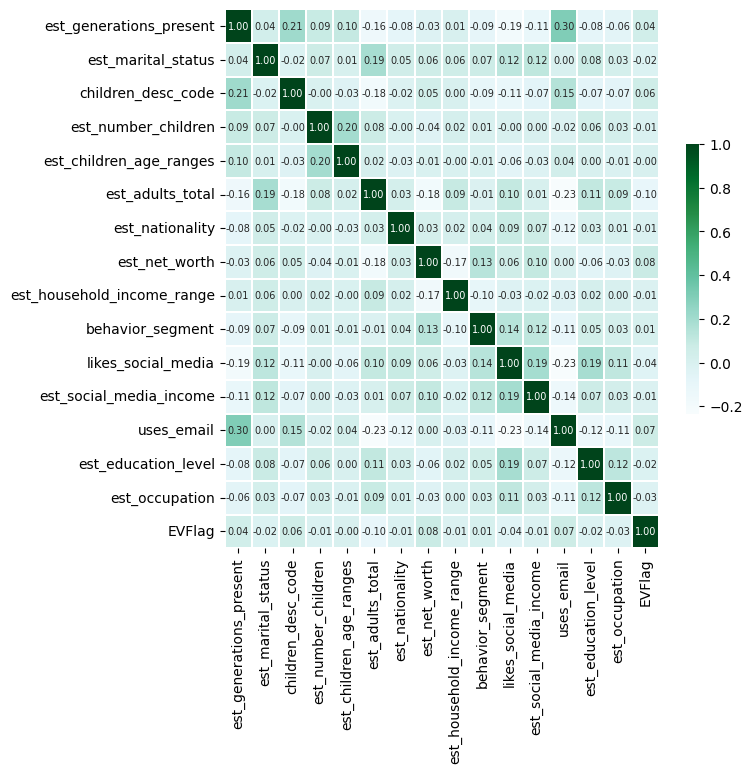

In [49]:
# Look at the Columns Correlation by Using HeatMap:
df_demographic =df[['est_generations_present','est_marital_status','children_desc_code','est_number_children','est_children_age_ranges',
                    'est_adults_total','est_nationality','est_net_worth','est_household_income_range','behavior_segment','likes_social_media',
                    'est_social_media_income','uses_email','est_education_level','est_occupation','EVFlag']]

plt.figure(figsize=(7,7))
sns.heatmap(df_demographic.corr(),annot=True,linewidths=0.1,fmt='.2f',cmap='BuGn', cbar_kws={'shrink': 0.5},annot_kws={"size": 7})

In [50]:
# Define the columns for which you want to plot the relationship with 'EVFlag'
cols = ['est_generations_present','est_marital_status','children_desc_code','est_number_children','est_children_age_ranges',
        'est_adults_total','est_nationality','est_net_worth','est_household_income_range','behavior_segment','likes_social_media',
        'est_social_media_income','uses_email','est_education_level','est_occupation','EVFlag']

# Create subplots
fig = make_subplots(rows=5, cols=3, subplot_titles=cols, vertical_spacing=0.1, horizontal_spacing=0.1)

color_map = {0: 'skyblue', 1: 'green'}

# Loop through columns and plot
for i, col in enumerate(cols):
    if i >= 15:
        break

    grouped = df.groupby([col, 'EVFlag']).size().reset_index(name='count')

    for ev_flag in grouped['EVFlag'].unique():
        df_temp = grouped[grouped['EVFlag'] == ev_flag]

        # Format the text for the bars
        text = df_temp['count'].apply(lambda x: f"{x/1000:.0f}K" if x >= 1000 else str(x))

        row = (i // 3) + 1
        col_pos = (i % 3) + 1

        fig.add_trace(go.Bar(x=df_temp[col], y=df_temp['count'], name=f'EVFlag {ev_flag}',
            text=text, textposition="inside", marker_color=color_map.get(ev_flag, 'gray')),row=row, col=col_pos)

# Update layout
fig.update_layout(height=2000,width=1100,title_text='Distribution of Demographics & Social Behavior Factors by EVFlag',barmode='group',showlegend=True)
fig.show()

In [51]:
# pairplot
cols = ['est_net_worth', 'est_household_income_range', 'est_adults_total', 'est_number_children','est_education_level','est_occupation', 'EVFlag']

# Create the scatter matrix
fig = px.scatter_matrix(df,dimensions=cols,color='EVFlag')


fig.update_layout( height=1000, width=1000, font=dict(size=14), title=dict(text="Scatter Matrix of Economical Factors by EVFlag",x=0.5))

# Rotate y-axis and x-axis tick labels
fig.update_xaxes(tickangle=90)
fig.update_yaxes(tickangle=90)

# Show the figure
fig.show()


Output hidden; open in https://colab.research.google.com to view.

#### 2. House & Property Characteristics:

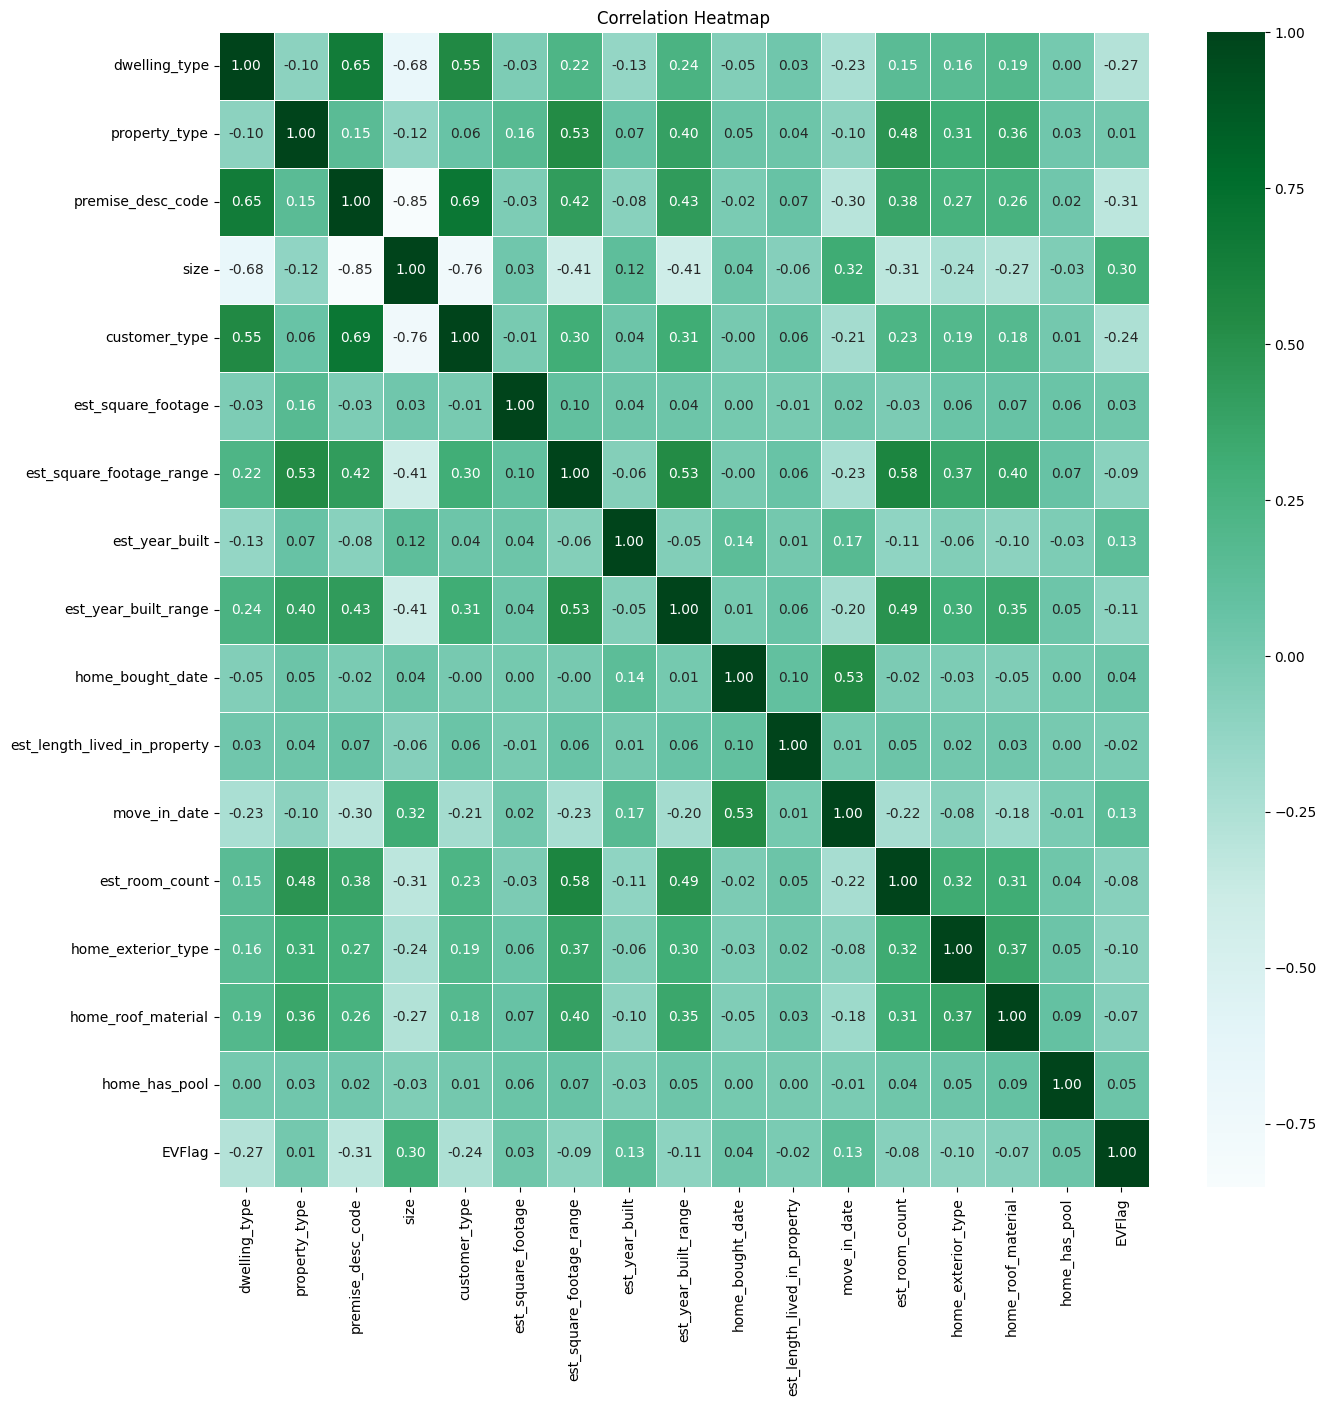

In [52]:
# Look at the Columns Correlation by Using HeatMap:
df_property_character = df[['dwelling_type','property_type','premise_desc_code','size','customer_type','est_square_footage','est_square_footage_range','est_year_built',
        'est_year_built_range','home_bought_date','est_length_lived_in_property','move_in_date','est_room_count','home_exterior_type',
        'home_roof_material','home_has_pool','EVFlag']]
df_encoded = df_property_character.copy()

# Convert categorical columns to numeric using label encoding
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Now, generate the heatmap with numeric values
plt.figure(figsize=(15,15))
sns.heatmap(df_encoded.corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='BuGn')

plt.title("Correlation Heatmap")
plt.show()


In [53]:
# Define the columns for which you want to plot the relationship with 'EVFlag'
cols = ['dwelling_type','property_type','premise_desc_code','size','customer_type','est_square_footage','est_square_footage_range','est_year_built',
        'est_year_built_range','home_bought_date','est_length_lived_in_property','move_in_date','est_room_count','home_exterior_type',
        'home_roof_material','home_has_pool','EVFlag']

# Create subplots
fig = make_subplots(rows=4, cols=4, subplot_titles=cols, vertical_spacing=0.1, horizontal_spacing=0.1)

color_map = {0: 'skyblue', 1: 'green'}

# Loop through columns and plot
for i, col in enumerate(cols):
    if i >= 16:
        break

    grouped = df.groupby([col, 'EVFlag']).size().reset_index(name='count')

    for ev_flag in grouped['EVFlag'].unique():
        df_temp = grouped[grouped['EVFlag'] == ev_flag]

        # Format the text for the bars
        text = df_temp['count'].apply(lambda x: f"{x/1000:.0f}K" if x >= 1000 else str(x))

        row = (i // 4) + 1
        col_pos = (i % 4) + 1

        fig.add_trace(go.Bar(x=df_temp[col], y=df_temp['count'], name=f'EVFlag {ev_flag}',
            text=text, textposition="inside", marker_color=color_map.get(ev_flag, 'gray')),row=row, col=col_pos)

# Update layout
fig.update_layout(height=1400,width=1100,title_text='Distribution of House & Property Characteristics Factors by EVFlag',barmode='group',showlegend=True)
fig.show()

In [54]:
# Create Sunburst Chart
grouped = df.groupby(['customer_type','premise_desc_code','size','est_year_built','EVFlag']).size().reset_index(name='count')

fig = px.sunburst(grouped, path=['customer_type','premise_desc_code','size','est_year_built'],
                  values='count',height=500,color="EVFlag",color_continuous_scale=px.colors.sequential.Viridis,
                  title="Shows EVFlag Ownership based on the Property Type:")

fig.show()


#### 3. Energy Consumption  & Solar Adoption:

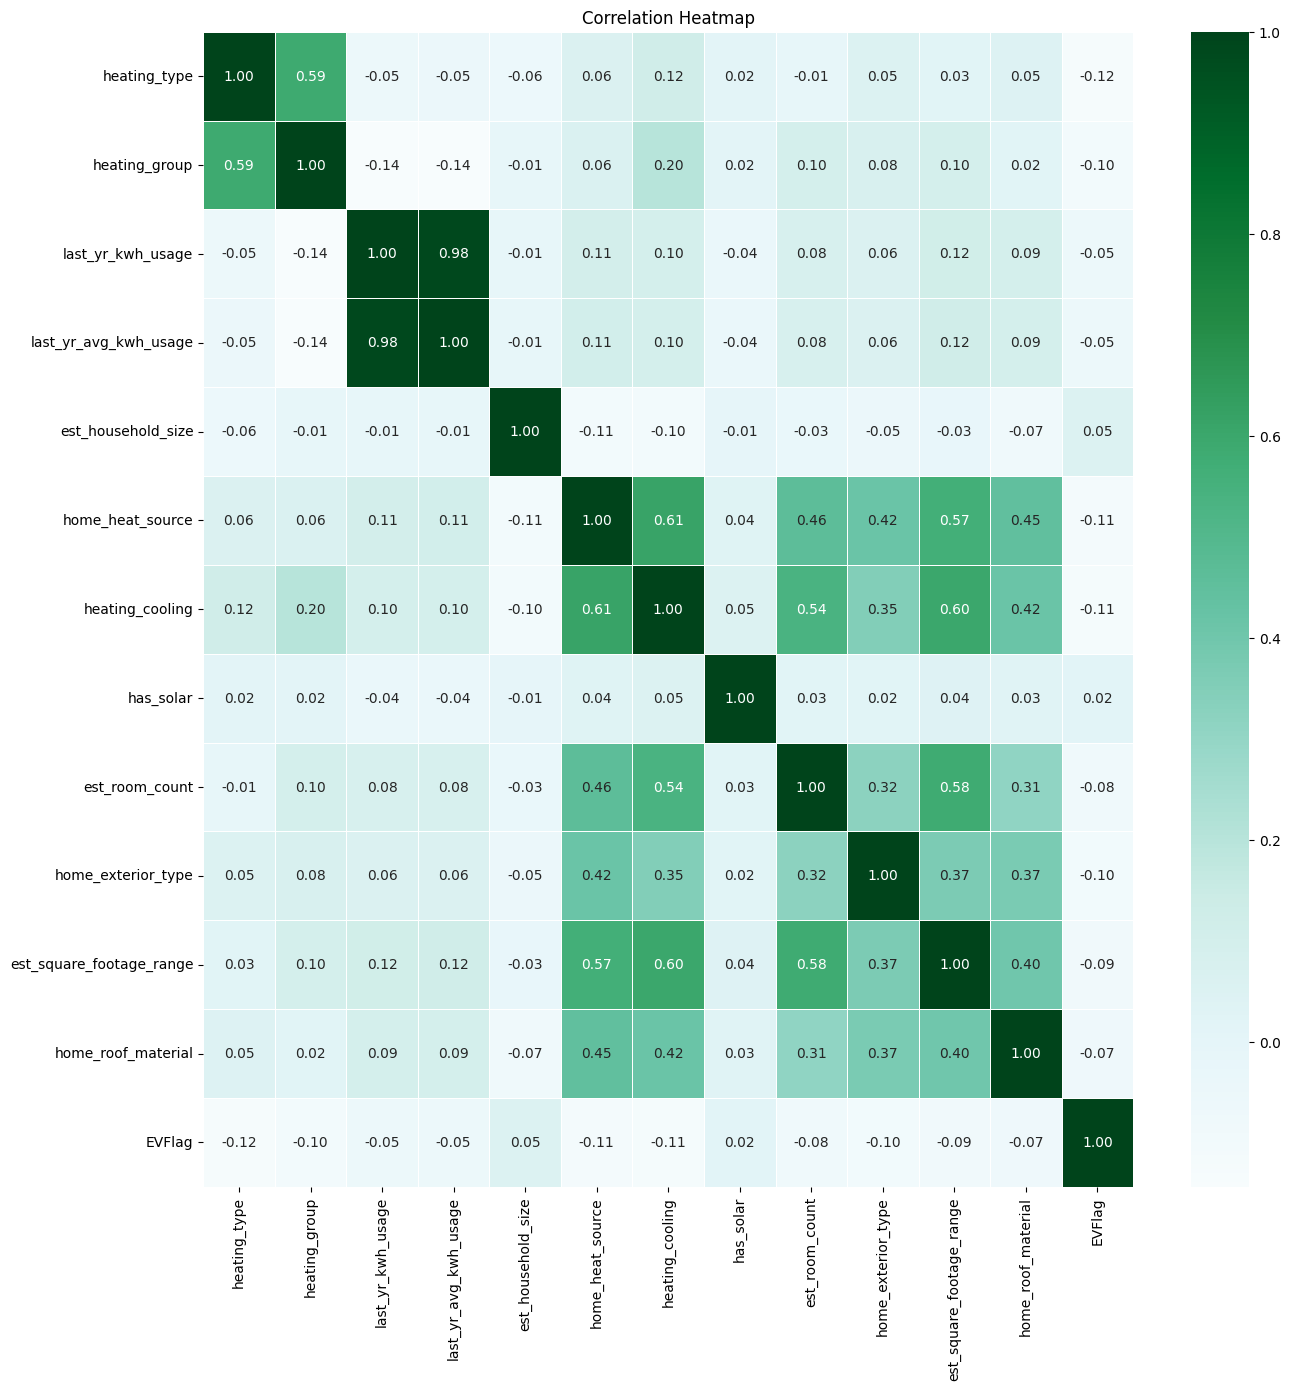

In [55]:
# Look at the Columns Correlation by Using HeatMap:
df_energy_consume = df[['heating_type','heating_group','last_yr_kwh_usage','last_yr_avg_kwh_usage','est_household_size','home_heat_source','heating_cooling','has_solar',
        'est_room_count','home_exterior_type','est_square_footage_range','home_roof_material','EVFlag']]

df_encoded = df_energy_consume.copy()

# Convert categorical columns to numeric using label encoding
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Now, generate the heatmap with numeric values
plt.figure(figsize=(15,15))
sns.heatmap(df_encoded.corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='BuGn')

plt.title("Correlation Heatmap")
plt.show()

In [56]:
# Define the columns for which you want to plot the relationship with 'EVFlag'
cols = ['heating_type','heating_group','last_yr_kwh_usage','last_yr_avg_kwh_usage','est_household_size','home_heat_source','heating_cooling','has_solar',
        'est_room_count','home_exterior_type','est_square_footage_range','home_roof_material']

# Create subplots
fig = make_subplots(rows=4, cols=3, subplot_titles=cols, vertical_spacing=0.1, horizontal_spacing=0.1)

color_map = {0: 'skyblue', 1: 'green'}

# Loop through columns and plot
for i, col in enumerate(cols):
    if i >= 12:
        break

    grouped = df.groupby([col, 'EVFlag']).size().reset_index(name='count')

    for ev_flag in grouped['EVFlag'].unique():
        df_temp = grouped[grouped['EVFlag'] == ev_flag]

        # Format the text for the bars
        text = df_temp['count'].apply(lambda x: f"{x/1000:.0f}K" if x >= 1000 else str(x))

        row = (i // 3) + 1
        col_pos = (i % 3) + 1

        fig.add_trace(go.Bar(x=df_temp[col],y=df_temp['count'],name=f'EVFlag {ev_flag}',text=text,textposition="inside",
                      marker_color=color_map.get(ev_flag, 'gray')),row=row, col=col_pos)

# Update layout
fig.update_layout(height=1400,width=1100,title_text='Distribution of Energy Consumption & Solar Adoption Factors by EVFlag',barmode='group',
                  showlegend=True)
fig.show()

In [57]:
# Create the Treemap
grouped = df.groupby(['heating_group','heating_type','home_heat_source','heating_cooling','EVFlag'])['EVFlag'].size().reset_index(name='count')


fig = px.treemap(grouped, path=[px.Constant("Energy Type"), 'heating_group','heating_type','home_heat_source','heating_cooling'],
                 color="EVFlag", values='count', color_continuous_scale=px.colors.sequential.Plasma,
                 title="Shows EVFlag Ownership based on the Energy Consumption:")

# Update layout for margins
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))

# Show the figure
fig.show()


In [58]:
# Show EVFlag based on the est_year_built, last_yr_avg_kwh_usage and Population :
fig = px.scatter(df, x="est_year_built", y="last_yr_avg_kwh_usage",size="est_population", color="EVFlag",
                 hover_name="premise_desc_code", log_x=True, size_max=60,)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

#### 4. Financial Stability & Economic Affordability:

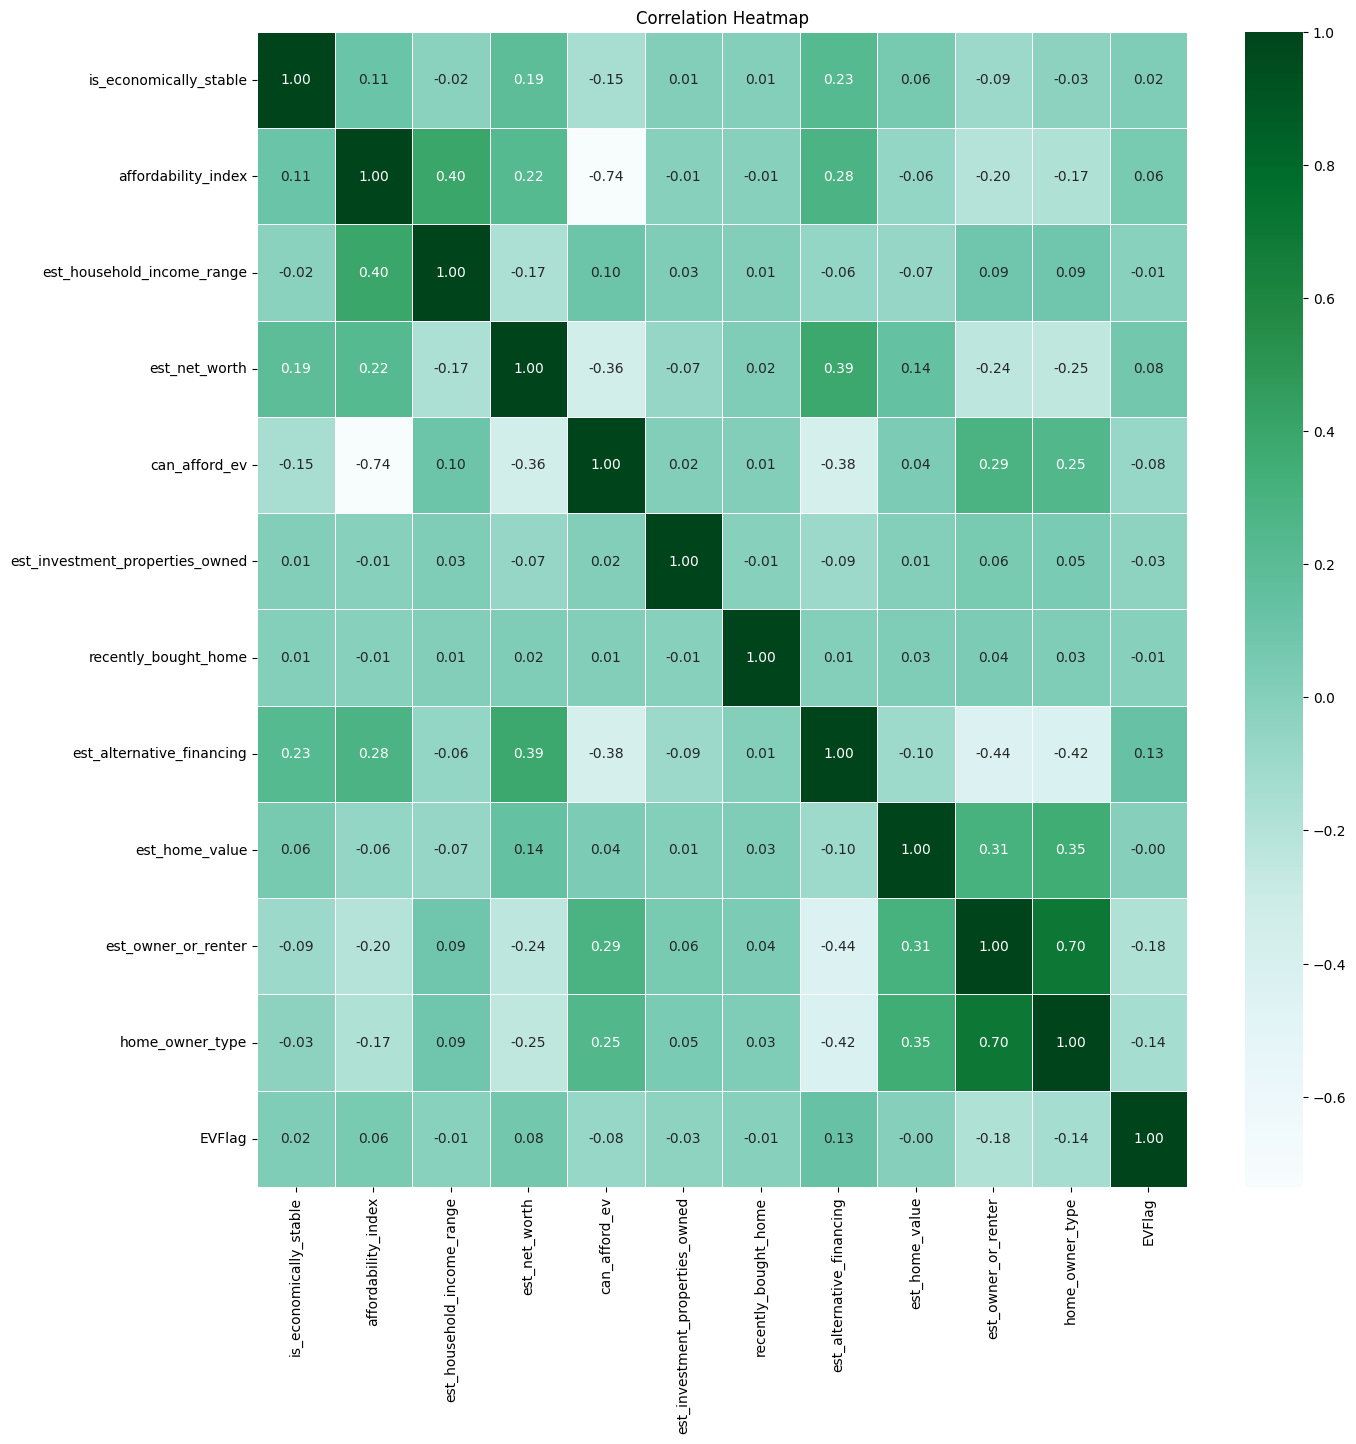

In [59]:
# Heatmap
df_economic = df[['is_economically_stable','affordability_index','est_household_income_range','est_net_worth','can_afford_ev','est_investment_properties_owned','recently_bought_home',
        'est_alternative_financing','est_home_value','est_owner_or_renter','home_owner_type','EVFlag']]
df_encoded = df_economic.copy()

# Convert categorical columns to numeric using label encoding
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Now, generate the heatmap with numeric values
plt.figure(figsize=(15,15))
sns.heatmap(df_encoded.corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='BuGn')

plt.title("Correlation Heatmap")
plt.show()

In [60]:
# Define the columns for which you want to plot the relationship with 'EVFlag'
cols = ['is_economically_stable','affordability_index','est_household_income_range','est_net_worth','can_afford_ev',
        'est_investment_properties_owned','recently_bought_home','est_alternative_financing','est_home_value','est_owner_or_renter',
        'home_owner_type']

# Create subplots
fig = make_subplots(rows=4, cols=3, subplot_titles=cols, vertical_spacing=0.1, horizontal_spacing=0.1)

color_map = {0: 'skyblue', 1: 'green'}

# Loop through columns and plot
for i, col in enumerate(cols):
    if i >= 12:
        break

    grouped = df.groupby([col, 'EVFlag']).size().reset_index(name='count')

    for ev_flag in grouped['EVFlag'].unique():
        df_temp = grouped[grouped['EVFlag'] == ev_flag]

        # Format the text for the bars
        text = df_temp['count'].apply(lambda x: f"{x/1000:.0f}K" if x >= 1000 else str(x))

        row = (i // 3) + 1
        col_pos = (i % 3) + 1

        fig.add_trace(go.Bar(x=df_temp[col],y=df_temp['count'],name=f'EVFlag {ev_flag}',text=text,textposition="inside",
                      marker_color=color_map.get(ev_flag, 'gray')),row=row, col=col_pos)

# Update layout
fig.update_layout(height=1400,width=1100,title_text='Distribution of Financial Stability & Economic Affordability Factors by EVFlag',barmode='group',
                  showlegend=True)
fig.show()

In [61]:
# Distribution of Affordability Index by EV Ownership by hist plot
fig = px.histogram(df,x='affordability_index',nbins=30,color='EVFlag',title='Distribution of Affordability Index by EV Ownership',
                   color_discrete_map={0: 'skyblue', 1: 'green'})

fig.update_layout(xaxis_title='Affordability Index',yaxis_title='Frequency',coloraxis_colorbar_title='EV Ownership (0 = No, 1 = Yes)')
fig.update_traces(marker=dict(line=dict(width=2, color='black')))  # Optional: Add border to bars for better clarity
fig.show()


Output hidden; open in https://colab.research.google.com to view.

#### 5. Values & Behavioral- Psychographic Traits

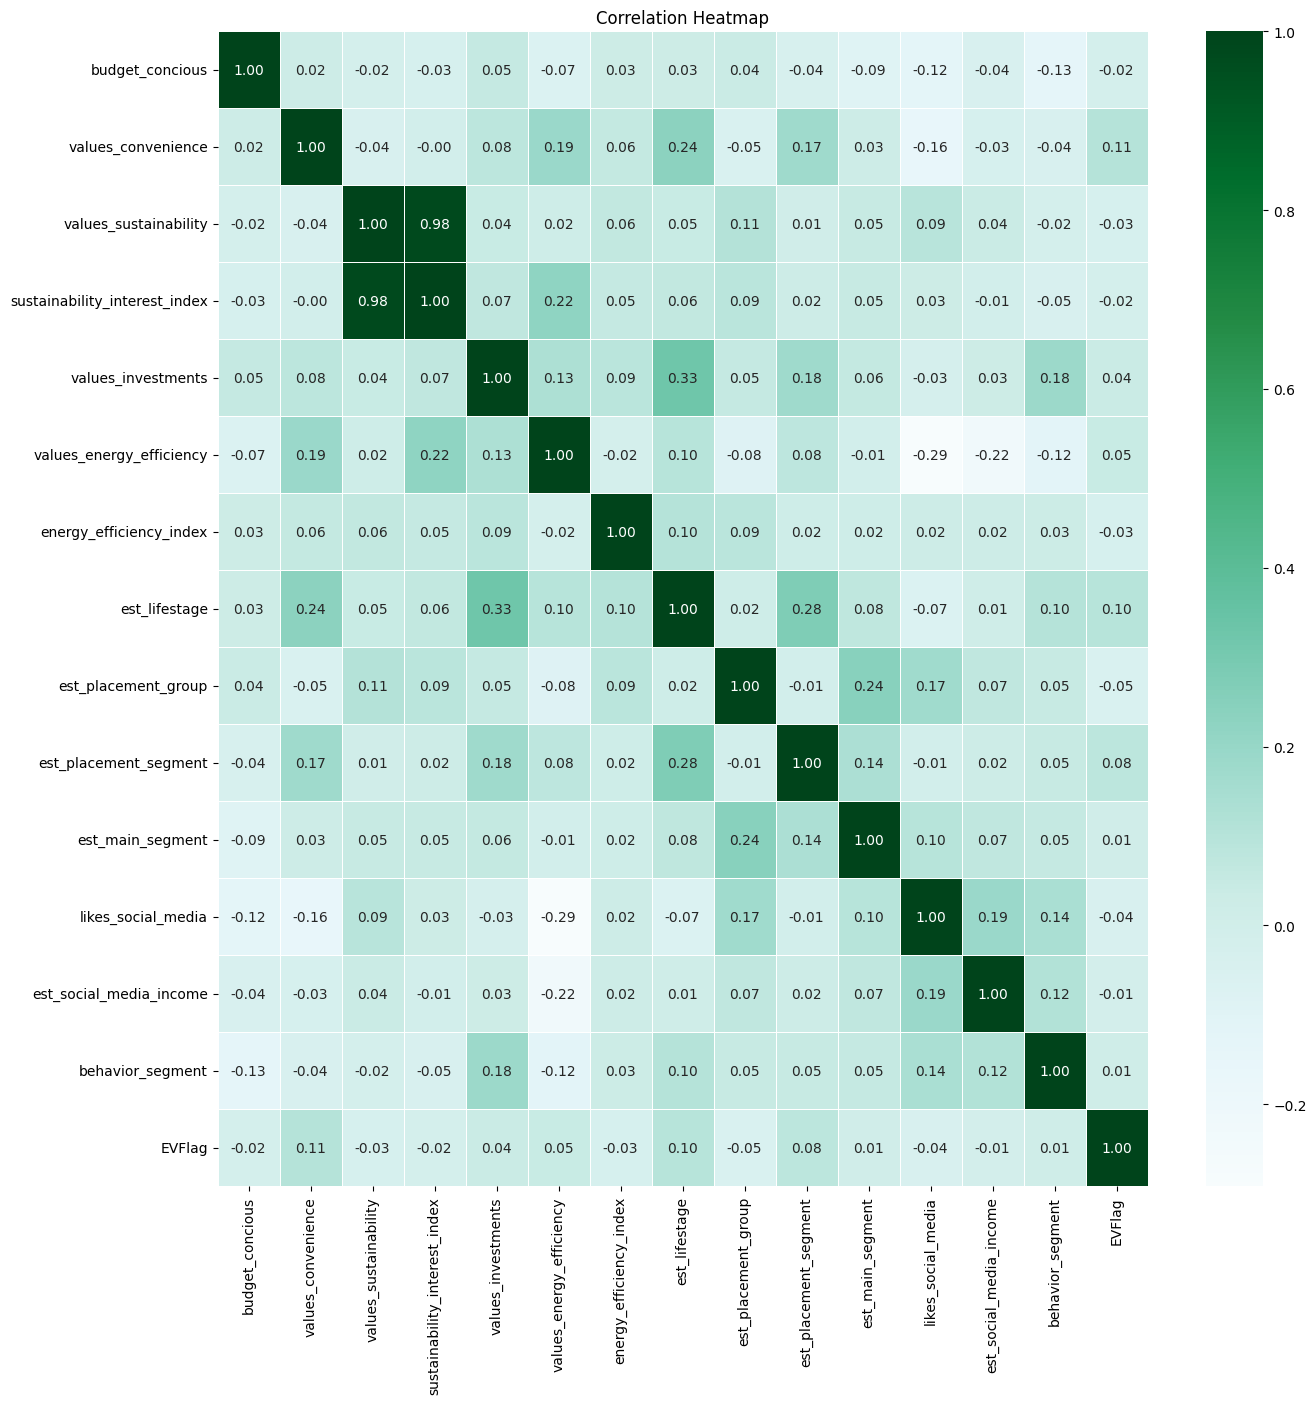

In [62]:
# Heatmap
df_values =df[['budget_concious','values_convenience','values_sustainability','sustainability_interest_index','values_investments',
               'values_energy_efficiency','energy_efficiency_index','est_lifestage','est_placement_group','est_placement_segment',
               'est_main_segment','likes_social_media','est_social_media_income','behavior_segment','EVFlag']]

df_encoded = df_values.copy()

# Convert categorical columns to numeric using label encoding
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Now, generate the heatmap with numeric values
plt.figure(figsize=(15,15))
sns.heatmap(df_encoded.corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='BuGn')

plt.title("Correlation Heatmap")
plt.show()

In [63]:
# Define the columns for which you want to plot the relationship with 'EVFlag'
cols = ['budget_concious','values_convenience','values_sustainability','sustainability_interest_index','values_investments','values_energy_efficiency',
        'energy_efficiency_index','est_placement_group','est_placement_segment','est_main_segment']

# Create subplots
fig = make_subplots(rows=3, cols=4, subplot_titles=cols, vertical_spacing=0.1, horizontal_spacing=0.1)

color_map = {0: 'skyblue', 1: 'green'}

# Loop through columns and plot
for i, col in enumerate(cols):
    if i >= 12:
        break

    grouped = df.groupby([col, 'EVFlag']).size().reset_index(name='count')

    for ev_flag in grouped['EVFlag'].unique():
        df_temp = grouped[grouped['EVFlag'] == ev_flag]

        # Format the text for the bars
        text = df_temp['count'].apply(lambda x: f"{x/1000:.0f}K" if x >= 1000 else str(x))

        row = (i // 4) + 1
        col_pos = (i % 4) + 1

        fig.add_trace(go.Bar(x=df_temp[col],y=df_temp['count'],name=f'EVFlag {ev_flag}',text=text,textposition="inside",
                      marker_color=color_map.get(ev_flag, 'gray')),row=row, col=col_pos)

# Update layout
fig.update_layout(height=1000,width=1100,title_text='Distribution of Values & Behavioral Traits Factors by EVFlag',barmode='group',
                  showlegend=True)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [64]:
# Energy Efficiency Distribution by EVFlag with Hist plot
fig = px.histogram(df,x='energy_efficiency_index',color='EVFlag',color_discrete_map={0: 'blue', 1: 'green'},barmode='overlay',
                   title='Energy Efficiency Distribution by EVFlag')

fig.update_layout(xaxis_title='Energy Efficiency', yaxis_title='Count')
fig.show()


Output hidden; open in https://colab.research.google.com to view.

#### 6. Geographic Factors:

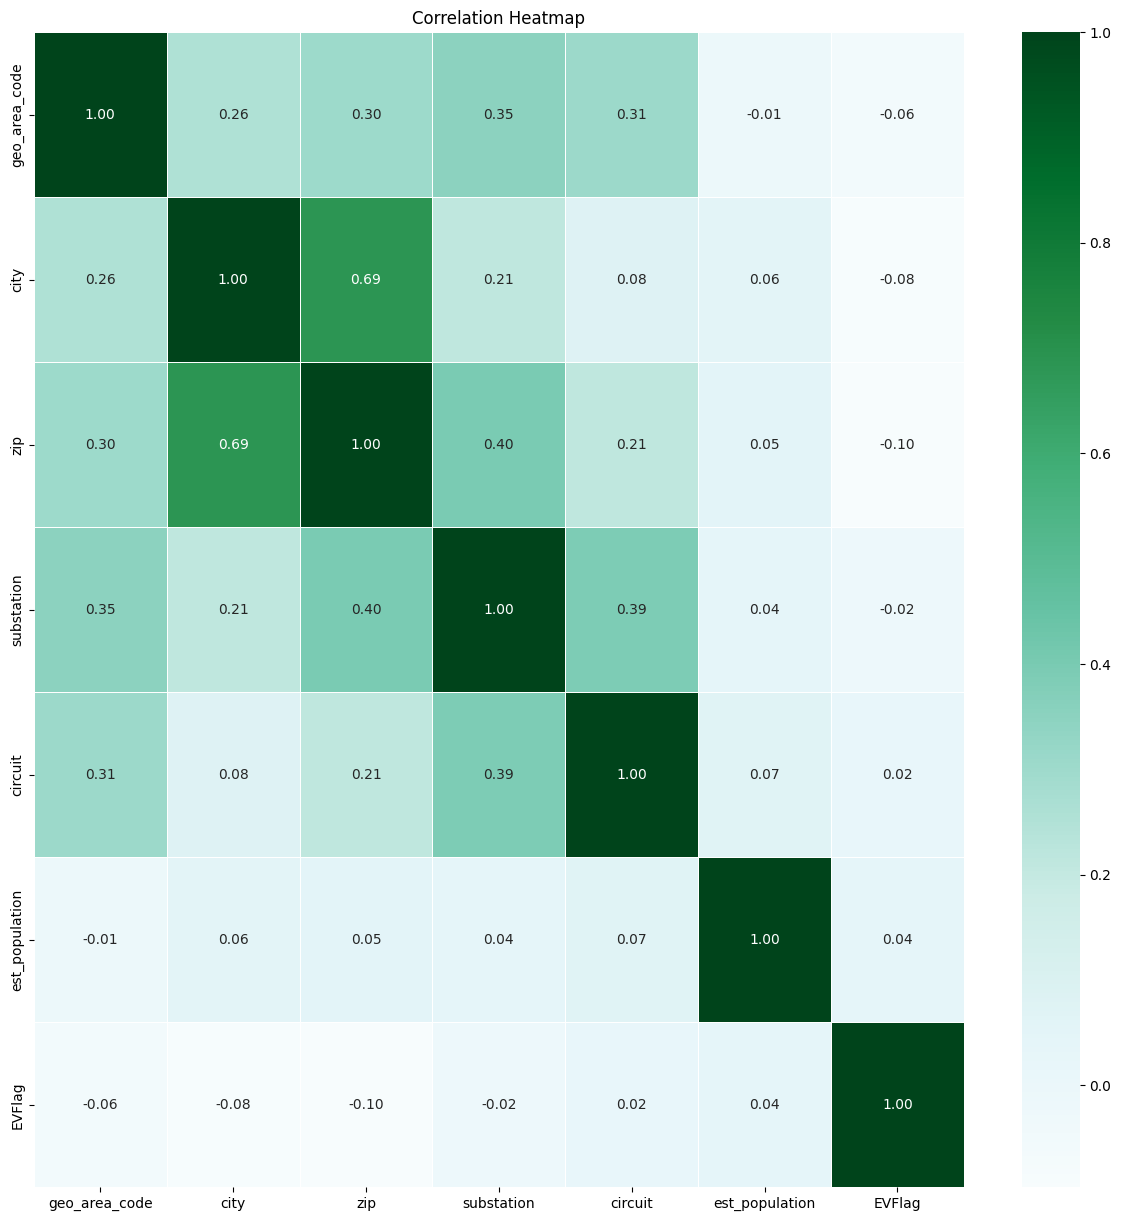

In [65]:
# Heatmap
df_geo=df[['geo_area_code', 'city', 'zip', 'substation', 'circuit','est_population','EVFlag']]

df_encoded = df_geo.copy()

# Convert categorical columns to numeric using label encoding
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Now, generate the heatmap with numeric values
plt.figure(figsize=(15,15))
sns.heatmap(df_encoded.corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='BuGn')

plt.title("Correlation Heatmap")
plt.show()

In [66]:
# Define the columns for which you want to plot the relationship with 'EVFlag'
cols = ['geo_area_code', 'city', 'zip', 'substation', 'circuit','est_population']

# Create subplots
fig = make_subplots(rows=3, cols=2, subplot_titles=cols, vertical_spacing=0.1, horizontal_spacing=0.1)

color_map = {0: 'skyblue', 1: 'green'}

# Loop through columns and plot
for i, col in enumerate(cols):
    if i >= 6:
        break

    grouped = df.groupby([col, 'EVFlag']).size().reset_index(name='count')

    for ev_flag in grouped['EVFlag'].unique():
        df_temp = grouped[grouped['EVFlag'] == ev_flag]

        # Format the text for the bars
        text = df_temp['count'].apply(lambda x: f"{x/1000:.0f}K" if x >= 1000 else str(x))

        row = (i // 2) + 1
        col_pos = (i % 2) + 1

        fig.add_trace(go.Bar(x=df_temp[col],y=df_temp['count'],name=f'EVFlag {ev_flag}',text=text,textposition="inside",
                      marker_color=color_map.get(ev_flag, 'gray')),row=row, col=col_pos)

# Update layout
fig.update_layout(height=1400,width=1100,title_text='Distribution of Geographic Location Factors by EVFlag',barmode='group',
                  showlegend=True)
fig.show()

In [67]:
# Create the Sankey chart

EVFlag_map = {0: 'No', 1: 'Yes'}
sankey_data = df_geo.groupby(['city', 'EVFlag']).size().reset_index(name='count')
sankey_data['EVFlag'] = sankey_data['EVFlag'].map(EVFlag_map)

sankey_data['city'] = sankey_data['city'].astype(str)

# Prepare the Sankey chart inputs
sources = []
targets = []
values = []
link_colors = []

cities = sankey_data['city'].unique()
ev_flag_categories = sankey_data['EVFlag'].unique()

# Iterate through combinations of city and EVFlag
for area in cities:
    for flag in ev_flag_categories:
        subset = sankey_data[(sankey_data['city'] == area) & (sankey_data['EVFlag'] == flag)]

        if not subset.empty:
            count = subset['count'].values[0]
            sources.append(area)
            targets.append(flag)
            values.append(count)

            # Assign color based on EVFlag (0 -> blue, 1 -> green)
            if flag == 'No':
                link_colors.append('skyblue')
            else:
                link_colors.append('green')

# Create the Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=list(cities) + list(ev_flag_categories),
    ),
    link=dict(
        source=[list(cities).index(source) for source in sources],
        target=[len(cities) + list(ev_flag_categories).index(target) for target in targets],
        value=values,
        color=link_colors,  # Apply the colors
    )
))

fig.update_layout(title_text="EV Ownership by City", font_size=10)
fig.show()


In [68]:
# Pie chart to show EV ownership by city
fig = px.pie(df_geo,
             names='zip',
             color='EVFlag',
             title='EV Ownership Distribution by ZipCode',
             color_discrete_map={0: 'skyblue', 1: 'green'})

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [72]:
!jupyter nbconvert --to pdf "/content/drive/My Drive/Colab Notebooks/EVdataset_EDA.ipynb"


[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/EVdataset_EDA.ipynb to pdf
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['text/html']) is not able to be represented.
  ((*- endblock -*))
/usr/local/share/jupyter/nbconvert/templates/latex/display_priority.j2:32: UserWarning: Your element with mimetype(s) 

In [ ]:
# @title Default title text
!jupyter nbconvert --to pdf --execute --embed-images "/content/drive/My Drive/Colab Notebooks/EVdataset_EDA.ipynb"


[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/EVdataset_EDA.ipynb to pdf
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_requ